# AD mouse: cell populations over time

Starting from the trained AD model, generate cell populations, assign cell
types, and plot their spatial distribution, proportions, and numbers.
This repeats the population analysis in Supplementary Fig. S26. To redraw
the exact saved simulation used in the paper, use the
[AD paper figures](../paper_figures/admouse_figures.md) page.

## Prepare the data and model

Follow [installation](../../installation.md), then extract `admouse_model.zip`
and `admouse_analysis_data.zip` from the [data page](../../data_checkpoints.md).
Set `PROJECT_DIR` below to the directory containing the extracted `data/` folder.
This notebook uses the model trained with an expression weight of 0.015.
For training from counts, see [Train a model](../../training.md).

In [1]:
from pathlib import Path
import os
import json
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import CytoBridge as cb

PROJECT_DIR = Path(os.environ.get("CYTOBRIDGE_PROJECT_DIR", ".")).resolve()
DATA_DIR = PROJECT_DIR / "data" / "admouse"
OUTPUT_DIR = PROJECT_DIR / "outputs" / "admouse_S26"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = "cuda"
SEED = 42
observed_times = [0.0, 1.0, 2.0]
times = list(np.round(np.arange(0, 2.41, 0.1), 1))
display_times = [0.0, 0.4, 0.7, 1.0, 1.2, 1.8, 2.0, 2.2]
palette = {
    "Astrocytes": "#1f77b4", "Excitatory neurons": "#ff7f0e",
    "Fibroblast": "#2ca02c", "Inhibitory neurons": "#d62728",
    "Microglia": "#9467bd", "OPC": "#8c564b",
    "Oligodendrocytes": "#e377c2", "Pericytes/Endothelial": "#7f7f7f",
}
plt.rcParams.update({
    "font.family": "Arial", "font.size": 9, "text.color": "black",
    "axes.labelcolor": "black", "xtick.color": "black", "ytick.color": "black",
    "pdf.fonttype": 42, "svg.fonttype": "none",
})

## Load the observed populations and model

Model times 0, 1, and 2 correspond to measured ages of 2.5, 5.7, and 17.9
months. `model_state_adata` reads the aligned coordinates and PCA scores
used for training. The classifier below is the one fitted with this model's
downstream analysis, and includes time among its inputs.

In [2]:
aligned = ad.read_h5ad(DATA_DIR / "aligned.h5ad", backed="r")
try:
    reference = cb.tl.model_state_adata(
        aligned, time_key="time_point_processed", latent_key="X_latent",
        spatial_key="spatial_aligned",
    )
finally:
    aligned.file.close()
observed = {t: reference[np.isclose(reference.obs["time_point_processed"], t)].copy()
            for t in observed_times}
loaded = cb.tl.load_dynamical_model_from_dir(
    DATA_DIR / "model", dim=reference.n_vars, device=DEVICE,
    edge_predictor_path=DATA_DIR / "edge_classifier" / "admouse_edge_model.pt",
)
classifier = cb.tl.load_cached_mlp_classifier(
    str(DATA_DIR / "classifier_cache" / "classifier_resmlp_46ee959d0b1f14db.pt"),
    device=DEVICE,
)
pd.Series({t: population.n_obs for t, population in observed.items()}, name="Observed cells")

0.0    53615
1.0    58447
2.0    60030
Name: Observed cells, dtype: int64

## Simulate the population

Start with all cells at t=0. The simulation includes growth-dependent
division and removal and continues without restarting at later observations.
The final displayed state extends slightly beyond the last measured age.
The output is one array of model states per requested time.

In [3]:
cb.tl.set_global_random_seed(SEED)
points = cb.tl.simulate_sde_points_split(
    adata=reference, model=loaded.model, dim=reference.n_vars,
    time_index=0, n_samples=observed[0.0].n_obs, ts_points=times,
    dt=0.01, sigma=0.03, growth_alpha=1.0, interaction_m=1024,
    device=DEVICE, time_key="time_point_processed", obsm_key=None,
    spatial_key="spatial", concat_spatial=False,
    resample_dt=None, max_particles=None, daughter_noise_std=0.0,
)

## Assign cell types

Predict each generated cell's type from its model state and time. A
neighbour count of one retains the classifier's prediction without spatial
majority-vote smoothing. Save every generated population for later analysis.

In [4]:
labels = cb.tl.predict_labels_for_trajectories(
    sde_points=points, ts_points=times, model=classifier.model,
    label_encoder=classifier.label_encoder, feature_dim=reference.n_vars,
    device=DEVICE, knn_neighbors=1, include_time_feature=True,
)
generated = {}
state_dir = OUTPUT_DIR / "generated_states"
state_dir.mkdir(exist_ok=True)
for time, values, celltypes in zip(times, points, labels):
    population = ad.AnnData(X=np.asarray(values, dtype=np.float32))
    population.obs["major_annotation"] = np.asarray(celltypes).astype(str)
    population.obsm["spatial"] = population.X[:, :2].copy()
    population.uns["time"] = float(time)
    generated[time] = population
    population.write_h5ad(state_dir / f"time_{time:g}.h5ad")
composition = cb.tl.summarize_label_composition(labels, times)
composition.to_csv(OUTPUT_DIR / "predicted_composition.csv", index=False)
counts = composition.pivot(index="time", columns="celltype", values="count").fillna(0)
counts = counts.reindex(columns=list(palette), fill_value=0)
counts.to_csv(OUTPUT_DIR / "predicted_counts.csv")
counts

celltype,Astrocytes,Excitatory neurons,Fibroblast,Inhibitory neurons,Microglia,OPC,Oligodendrocytes,Pericytes/Endothelial
time,,,,,,,,
0.0,7558,19636,3159,8666,1795,1405,7343,4053
0.1,7652,19620,3146,8801,1822,1408,7541,4097
0.2,7745,19577,3120,8945,1851,1407,7760,4129
0.3,7871,19483,3099,9138,1888,1421,7977,4174
0.4,8006,19375,3095,9351,1916,1424,8197,4188
0.5,8153,19256,3087,9578,1945,1431,8417,4223
0.6,8281,19126,3080,9805,1976,1442,8640,4260
0.7,8441,18999,3075,9984,2013,1446,8865,4300
0.8,8592,18823,3078,10183,2051,1449,9104,4334


## Prepare the three panels

All three panels use the generated trajectory, including at t=0, 1, and 2.
Solid frames mark the times at which measurements were available. They do
not replace a generated population with measured cells.

Use the age labels supplied with the paper's source data. Model time 2.2
is displayed as 19.4 months. States after t=2 are extrapolations beyond the
last observed age. The values below retain the manuscript's rounded labels.

In [5]:
age_labels = [2.5, 2.8, 3.1, 3.5, 3.8, 4.1, 4.4, 4.7, 5.1, 5.4,
              5.7, 6.9, 8.1, 9.4, 10.6, 11.8, 13.0, 14.2, 15.5, 16.7,
              17.9, 18.7, 19.4, 20.2, 21.0]
ages = dict(zip(times, age_labels))
spatial_populations = {t: generated[t] for t in display_times}
proportions = counts.div(counts.sum(axis=1), axis=0)
proportions.to_csv(OUTPUT_DIR / "displayed_proportions.csv")
pd.DataFrame({"model_time": times, "age_months": [ages[t] for t in times],
              "observed": [t in observed for t in times]}).to_csv(
    OUTPUT_DIR / "time_mapping.csv", index=False,
)

## Draw the population panels

`plot_population_overview` reads the populations and tables above. Spatial
planes are evenly spaced for display and labelled by age. Proportions and
counts use all cells. Spatial points are sampled only for display. Dashed
outlines mark times between or beyond the measured stages. A new stochastic
simulation can differ slightly from the saved trajectory used in S26.

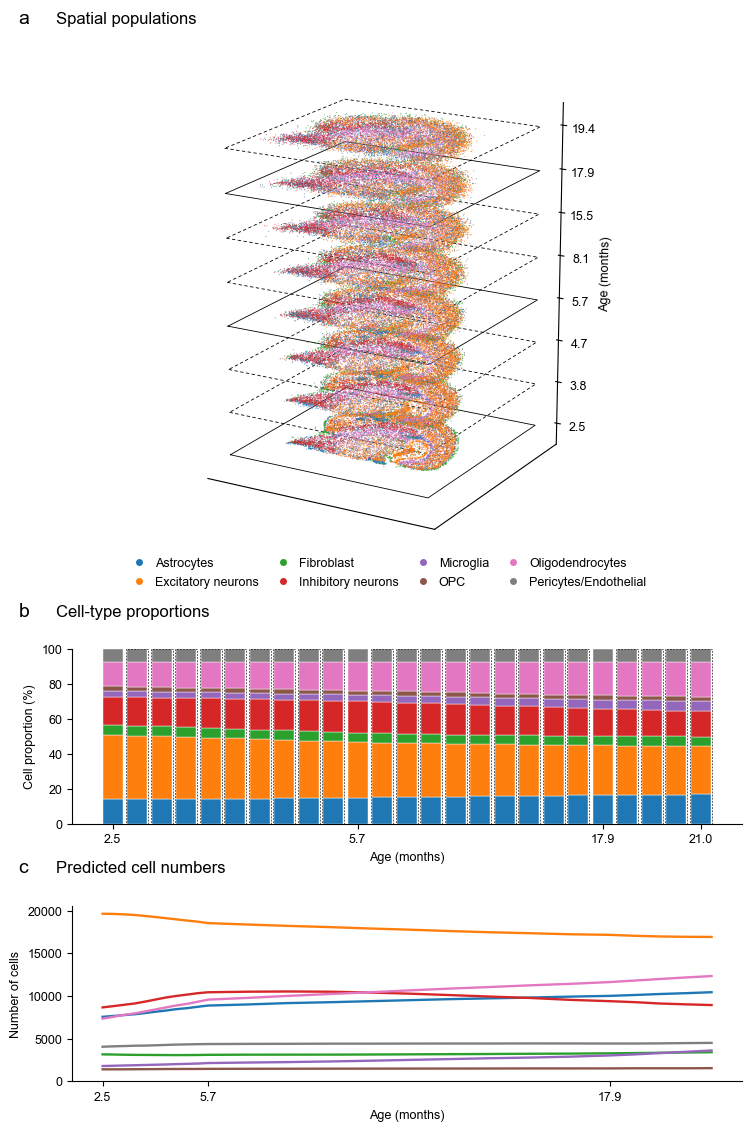

In [6]:
fig, axes = cb.pl.plot_population_overview(
    spatial_populations, proportions, counts,
    palette=palette, observed_times=observed_times, ages=ages,
    annotation_key="major_annotation", max_points_per_stage=10000, random_seed=SEED,
)
fig.savefig(OUTPUT_DIR / "admouse_S26.pdf")
fig.savefig(OUTPUT_DIR / "admouse_S26.png", dpi=300)
plt.show()

## Keep the calculation settings

Save the model files and settings alongside the numerical outputs. To
change the display later, reopen `generated_states/`, `predicted_counts.csv`,
`displayed_proportions.csv`, and `time_mapping.csv`. The simulation does not
need to run again.

In [7]:
record = {
    "model_dir": str(DATA_DIR / "model"),
    "weight_stage": loaded.weight_stage, "score_stage": loaded.score_stage,
    "expression_weight": 0.015, "seed": SEED,
    "initial_cells": observed[0.0].n_obs, "time_points": times,
    "dt": 0.01, "sigma": 0.03, "growth_alpha": 1.0,
    "interaction_group_size": 1024, "classifier_neighbors": 1,
    "spatial_display_cap": 10000,
}
(OUTPUT_DIR / "analysis_settings.json").write_text(json.dumps(record, indent=2))

696

Continue with [AD paper figures](../paper_figures/admouse_figures.md) for
temporal gene programs, ligand–receptor profiles, NicheNet, and perturbations.